In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
btc = pd.read_csv('Bitcoin.csv')
xrp = pd.read_csv('XRP.csv')
sol = pd.read_csv('Solana.csv')

In [29]:
btc['Currency'] = 'Bitcoin'
xrp['Currency'] = 'XRP'
sol['Currency'] = 'Solana'

In [30]:
#Combine Data Sets
df = pd.concat([btc, xrp, sol])

df.head()

,SNo,Date,Price,Open,High,Low,Vol.,Change %,Currency
0,1,2010-07-18,0.1,0.0,0.1,0.1,80.0,0.0,Bitcoin
1,2,2010-07-19,0.1,0.1,0.1,0.1,570.0,0.0,Bitcoin
2,3,2010-07-20,0.1,0.1,0.1,0.1,260.0,0.0,Bitcoin
3,4,2010-07-21,0.1,0.1,0.1,0.1,580.0,0.0,Bitcoin
4,5,2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.0,Bitcoin


In [35]:
def convert_volume(vol):
    if isinstance(vol, str):
        if 'K' in vol:
            return float(vol.replace('K','')) * 1_000
        elif 'M' in vol:
            return float(vol.replace('M','')) * 1_000_000
        elif 'B' in vol:
            return float(vol.replace('B','')) * 1_000_000_000
        else:
            return float(vol.replace(',',''))
    return vol

df['Volume'] = df['Vol.'].apply(convert_volume)

In [36]:
# Returns
df['Return'] = df.groupby('Currency')['Price'].pct_change()

# Volatility (7-day rolling)
df['Volatility'] = df.groupby('Currency')['Return'].rolling(7).std().reset_index(0,drop=True)

In [37]:
df.head()

,SNo,Date,Price,Open,High,Low,Vol.,Change %,Currency,Volume,Return,Volatility
3454,3455,2020-01-01,7199.8,7196.4,7259.4,7180.0,420280.0,0.05,Bitcoin,420280.0,NaN,NaN
3455,3456,2020-01-02,6967.0,7199.7,7209.6,6901.4,632780.0,-3.23,Bitcoin,632780.0,-0.032334,NaN
3456,3457,2020-01-03,7343.1,6967.1,7402.9,6884.1,936290.0,5.40,Bitcoin,936290.0,0.053983,NaN
3457,3458,2020-01-04,7376.8,7345.1,7433.1,7291.4,523910.0,0.46,Bitcoin,523910.0,0.004589,NaN
3458,3459,2020-01-05,7372.5,7376.8,7501.0,7345.6,628140.0,-0.06,Bitcoin,628140.0,-0.000583,NaN


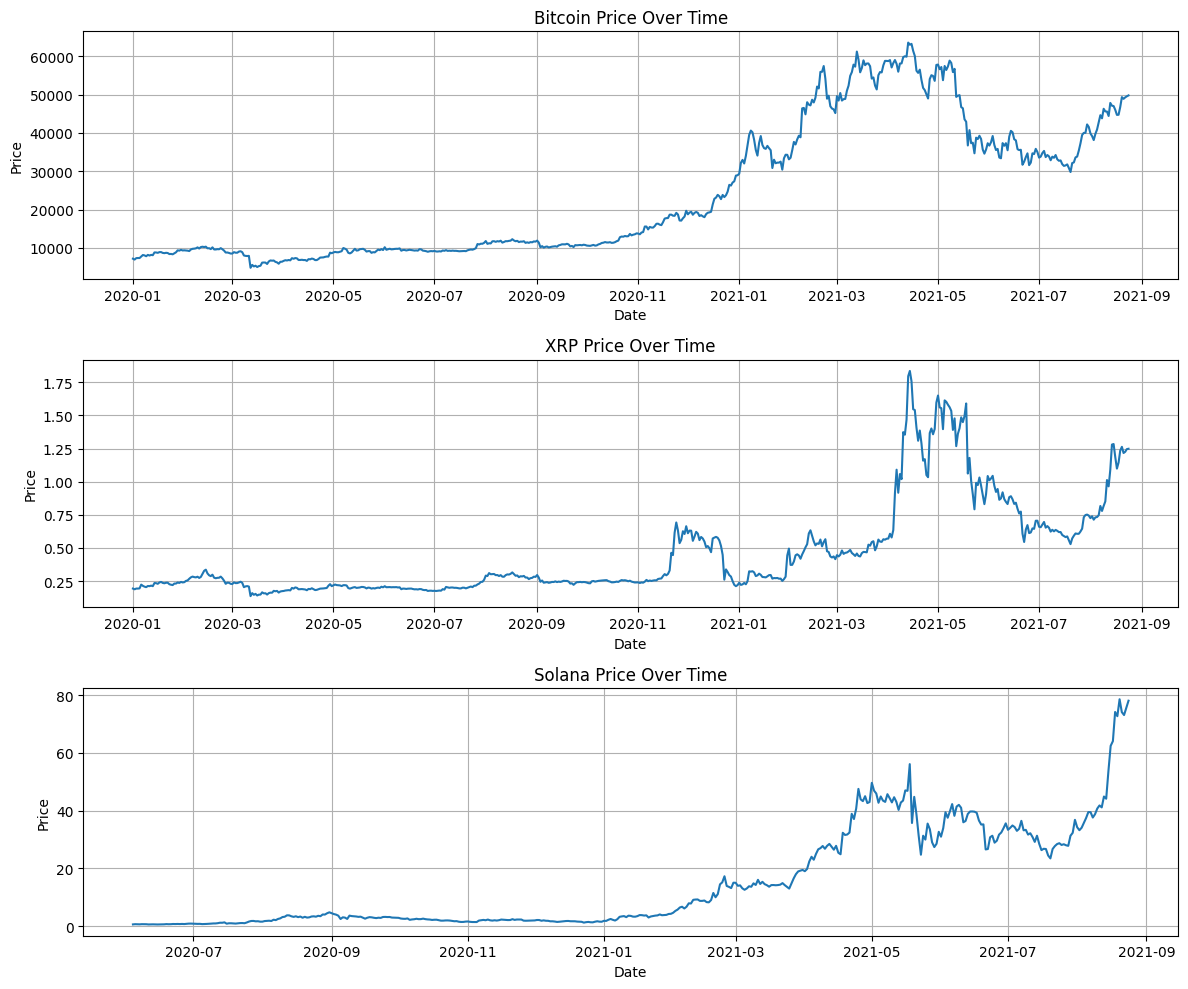

In [68]:
import matplotlib.pyplot as plt

coins = ['Bitcoin', 'XRP', 'Solana']

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for ax, coin in zip(axes, coins):
    temp = df[df['Currency'] == coin].copy()

    ax.plot(temp['Date'], temp['Price'])
    ax.set_title(f"{coin} Price Over Time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.grid(True)

plt.tight_layout()

fig.savefig("price_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

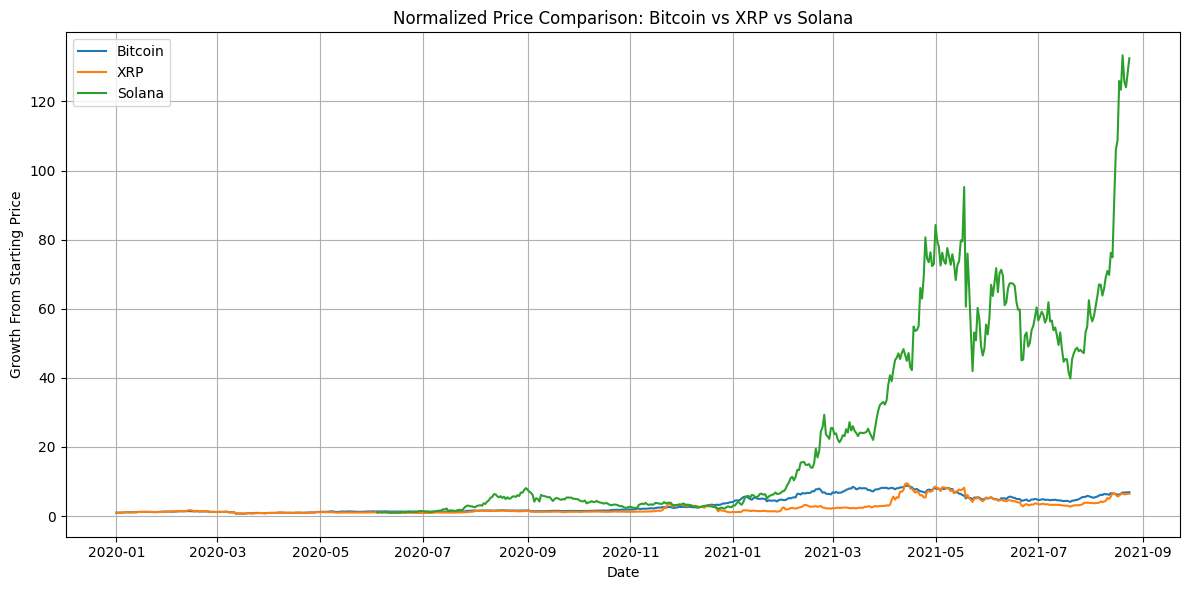

In [70]:
import matplotlib.pyplot as plt

coins = ['Bitcoin', 'XRP', 'Solana']

fig, ax = plt.subplots(figsize=(12,6))

for coin in coins:
    temp = df[df['Currency'] == coin].copy()
    temp['Normalized'] = temp['Price'] / temp['Price'].iloc[0]
    ax.plot(temp['Date'], temp['Normalized'], label=coin)

ax.legend()
ax.set_title("Normalized Price Comparison: Bitcoin vs XRP vs Solana")
ax.set_xlabel("Date")
ax.set_ylabel("Growth From Starting Price")
ax.grid(True)

plt.tight_layout()
fig.savefig("normalized_price.png", dpi=300, bbox_inches="tight")
plt.show()

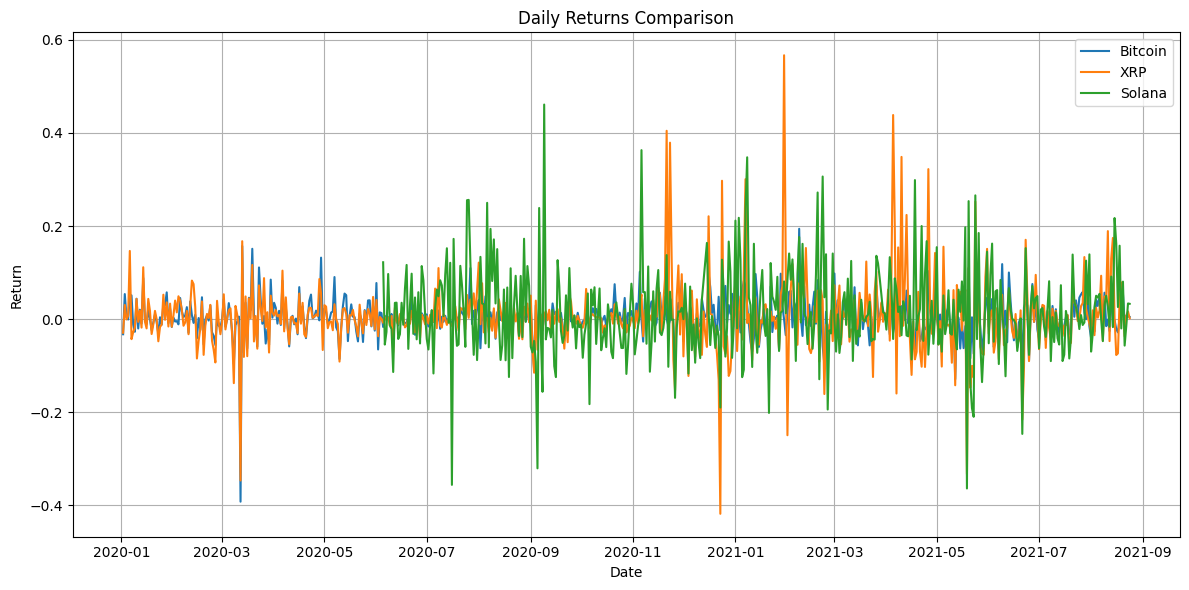

In [71]:
fig, ax = plt.subplots(figsize=(12,6))

for coin in coins:
    temp = df[df['Currency'] == coin]
    ax.plot(temp['Date'], temp['Return'], label=coin)

ax.legend()
ax.set_title("Daily Returns Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Return")
ax.grid(True)

plt.tight_layout()
fig.savefig("returns.png", dpi=300, bbox_inches="tight")
plt.show()

The daily returns graph shows frequent fluctuations across all cryptocurrencies. Solana exhibits larger spikes, indicating higher short-term variability, while Bitcoin appears more stable.

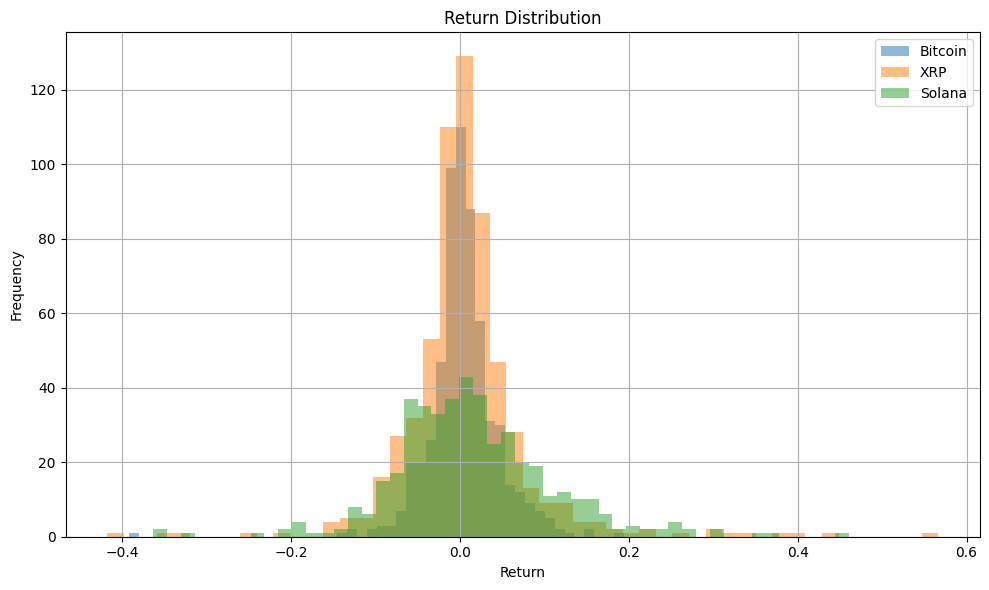

In [72]:
fig, ax = plt.subplots(figsize=(10,6))

for coin in coins:
    temp = df[df['Currency'] == coin]
    ax.hist(temp['Return'].dropna(), bins=50, alpha=0.5, label=coin)

ax.legend()
ax.set_title("Return Distribution")
ax.set_xlabel("Return")
ax.set_ylabel("Frequency")
ax.grid(True)

plt.tight_layout()
fig.savefig("return_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

The return distribution shows that Solana has a wider spread of returns, indicating higher risk. Bitcoin’s distribution is more concentrated, suggesting relatively lower volatility.

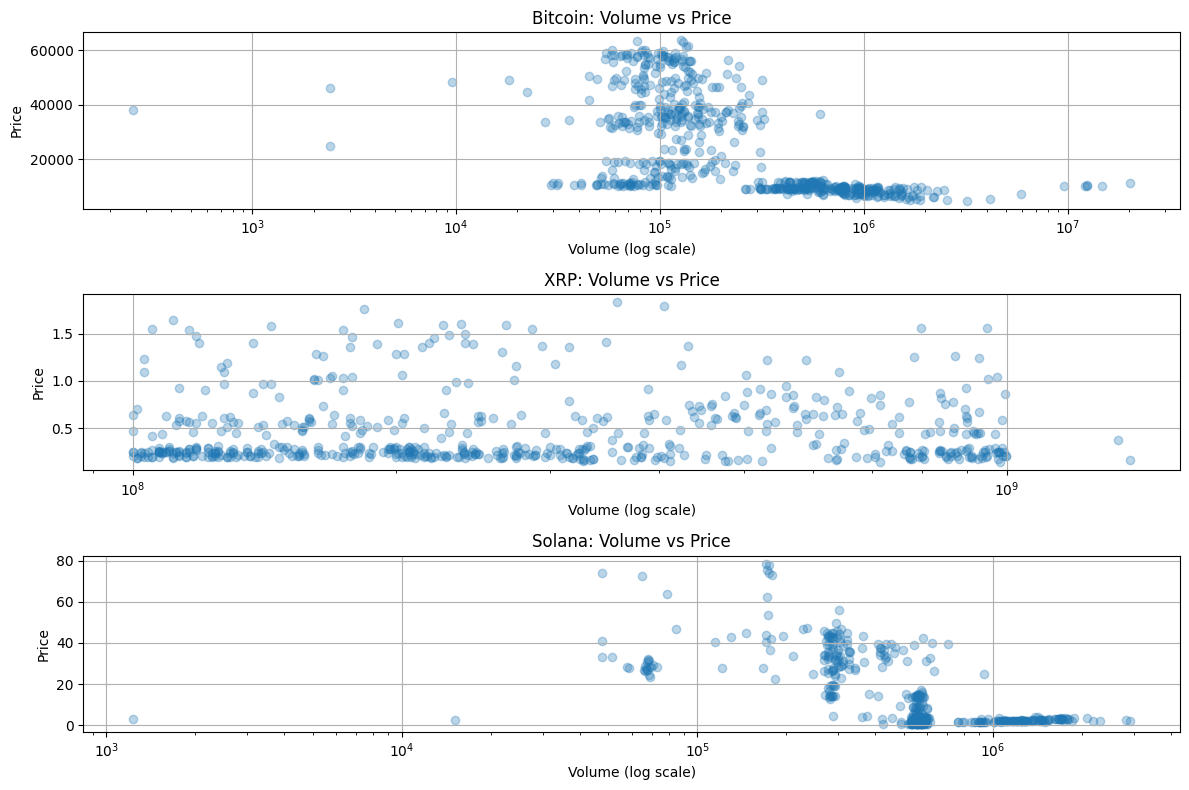

In [44]:
coins = ['Bitcoin','XRP','Solana']

plt.figure(figsize=(12,8))

for i, coin in enumerate(coins, 1):
    plt.subplot(3,1,i)

    temp = df[df['Currency'] == coin]

    plt.scatter(temp['Volume'], temp['Price'], alpha=0.3)
    plt.xscale('log')

    plt.title(f"{coin}: Volume vs Price")
    plt.xlabel("Volume (log scale)")
    plt.ylabel("Price")
    plt.grid()

plt.tight_layout()
plt.show()

The relationship between trading volume and price becomes clearer when analyzing each cryptocurrency separately. Bitcoin shows a stronger clustering pattern, while XRP and Solana exhibit lower price ranges with varying trading volumes. This highlights differences in market activity across cryptocurrencies.

#Correlation Analysis

In [45]:
#Bitcoin
btc = df[df['Currency'] == 'Bitcoin']

btc[['Price','Open','High','Low','Volume','Return','Volatility']].corr()

,Price,Open,High,Low,Volume,Return,Volatility
Price,1.000000,0.997422,0.998890,0.998554,-0.262482,0.019843,0.155178
Open,0.997422,1.000000,0.998889,0.997916,-0.259936,-0.038981,0.155274
High,0.998890,0.998889,1.000000,0.997770,-0.259860,-0.008683,0.165652
Low,0.998554,0.997916,0.997770,1.000000,-0.263620,-0.003212,0.141588
Volume,-0.262482,-0.259936,-0.259860,-0.263620,1.000000,-0.066775,0.148706
Return,0.019843,-0.038981,-0.008683,-0.003212,-0.066775,1.000000,-0.021214
Volatility,0.155178,0.155274,0.165652,0.141588,0.148706,-0.021214,1.000000


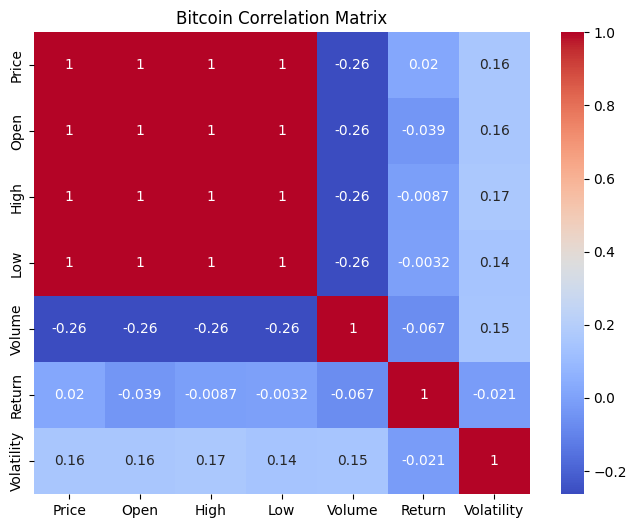

In [46]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    btc[['Price','Open','High','Low','Volume','Return','Volatility']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Bitcoin Correlation Matrix")
plt.show()

The correlation matrix shows strong positive relationships between price, open, high, and low values, which is expected as they are directly related market indicators. Returns and volatility show weaker correlations, indicating that short-term price movements are more unpredictable.

In [ ]:
#XRP
xrp = df[df['Currency'] == 'XRP']

xrp[['Price','Open','High','Low','Volume','Return','Volatility']].corr()

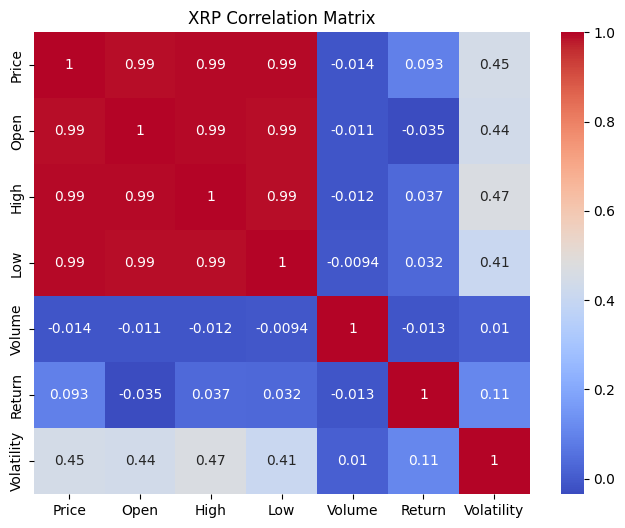

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

xrp = df[df['Currency'] == 'XRP']

plt.figure(figsize=(8,6))

sns.heatmap(
    xrp[['Price','Open','High','Low','Volume','Return','Volatility']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("XRP Correlation Matrix")
plt.show()

The correlation matrix for XRP shows strong relationships between price and market indicators such as open, high, and low values. However, returns and volatility exhibit weaker correlations, indicating more unpredictable short-term price movements.

In [49]:
#Solana
sol = df[df['Currency'] == 'Solana']

sol[['Price','Open','High','Low','Volume','Return','Volatility']].corr()

,Price,Open,High,Low,Volume,Return,Volatility
Price,1.000000,0.992617,0.996974,0.996805,-0.560153,0.041955,-0.073202
Open,0.992617,1.000000,0.996352,0.996940,-0.559163,-0.034747,-0.070013
High,0.996974,0.996352,1.000000,0.995044,-0.557505,0.008748,-0.059775
Low,0.996805,0.996940,0.995044,1.000000,-0.562660,-0.000018,-0.087612
Volume,-0.560153,-0.559163,-0.557505,-0.562660,1.000000,-0.032531,0.172419
Return,0.041955,-0.034747,0.008748,-0.000018,-0.032531,1.000000,0.095482
Volatility,-0.073202,-0.070013,-0.059775,-0.087612,0.172419,0.095482,1.000000


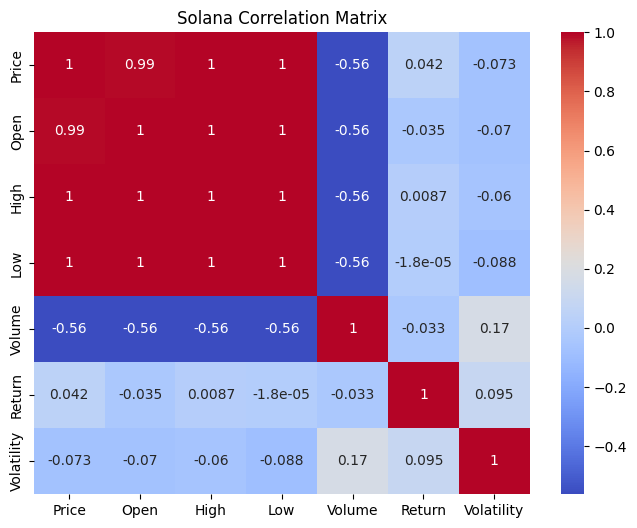

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(
    sol[['Price','Open','High','Low','Volume','Return','Volatility']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Solana Correlation Matrix")
plt.show()

The correlation analysis for Solana reveals strong relationships among price-related variables, similar to other cryptocurrencies. However, volatility tends to be higher, suggesting increased risk and more significant price fluctuations compared to Bitcoin and XRP.

#Models

In [58]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MAE: 0.034536149890206924
RMSE: 0.04595409563412457
R2: -0.014710906024297365


In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))


Random Forest Results:
MAE: 0.03482491435912681
RMSE: 0.04598164772128355
R2: -0.015928024279489028


In [60]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2:", r2_score(y_test, y_pred_xgb))


XGBoost Results:
MAE: 0.03600521438711633
RMSE: 0.04806510214283214
R2: -0.11007831737176921


In [61]:
results = pd.DataFrame({
    'Model': ['Ridge','Linear','Random Forest','XGBoost'],
    'MAE': [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    'R2': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

results

,Model,MAE,RMSE,R2
0,Ridge,0.034554,0.045962,-0.015079
1,Linear,0.034536,0.045954,-0.014711
2,Random Forest,0.034825,0.045982,-0.015928
3,XGBoost,0.036005,0.048065,-0.110078


Multiple machine learning models were applied, including Linear Regression, Ridge Regression, Random Forest, and XGBoost. The results show that no model achieved high predictive accuracy, confirming that cryptocurrency returns are difficult to forecast. Linear and Ridge Regression performed similarly, while more complex models such as Random Forest and XGBoost did not significantly improve performance. This suggests that the underlying data is highly noisy and lacks strong predictive patterns.